# Kinetic and canonic momentum comparison with or without Coulomb gauge

### Simulation parameters

In [1]:
import numpy as np

# hbar * c [GeV * fm]
hbarc = 0.197326 

# Simulation box 
L = 1.0      
# N = 256
N = 64
tau_sim = 0.2
DTS = 16
# DTS = 8

# Derived parameters
a = L/N
E0 = N / L * hbarc
DT = 1.0 / DTS
maxt = int(tau_sim / a * DTS)
nplus = maxt//DTS

# Glasma fields
su_group = 'su3'
uv = 10.0
ir = 0.2
g2mu = 1.5

g = 2         		
mu = g2mu / g**2

ns = 50      

nevents = 1
quark = 'jet' # 'jet' or 'static'            
# quark = 'static'

coulomb_gauge_mode = 'every_step' # 'none' or 'every_step' or 'initial'
# coulomb_gauge_mode = 'initial'

### Enviroment variables

In [2]:
import os

os.environ["MY_NUMBA_TARGET"] = "numba"
import warnings
from numba.core.errors import NumbaPerformanceWarning
warnings.filterwarnings('ignore', category=NumbaPerformanceWarning)

# Comment this, I need it for JYU GPUs to choose a specific GPU to run on
# os.environ["CUDA_VISIBLE_DEVICES"]="1"
# os.environ["MY_NUMBA_TARGET"] = "cuda"
os.environ["PRECISION"] = "double"
os.environ["GAUGE_GROUP"] = su_group

# Import relevant modules
import sys
sys.path.append('..')

# Glasma modules
import curraun.core as core
import curraun.mv as mv
import curraun.initial as initial
initial.DEBUG = False

from curraun.numba_target import use_cuda
if use_cuda:
    from numba import cuda

# Qhat module
if quark=='jet':
    import curraun.qhat_qeik as qeik
    import curraun.qhat_original as qhat
    # import curraun.qhat_qeik_old as qeik
elif quark=='static':
    import curraun.kappa_qeik as qeik
    import curraun.kappa as qhat

import curraun.coulomb as coulomb
coulomb.DEBUG = False

from tqdm import tqdm

Using Numba
Using SU(3)
Using double precision


In [3]:
def simulate_qhat(ev, coulomb_gauge_mode='none'): 
    """
    Run qhat simulation with optional Coulomb gauge fixing.
    
    Parameters:
    -----------
    ev : int
        Event number for progress display
    coulomb_gauge_mode : str
        'none' - no Coulomb gauge fixing
        'initial' - apply Coulomb gauge only at initial time (tint=tstart, when a0 is computed)
        'every_step' - apply Coulomb gauge at every timestep
    """
    # Derived parameters
    a = L / N
    E0 = N / L * hbarc
    DT = 1.0 / DTS
    maxt = int(tau_sim / a * DTS)

    # Initialize Glasma fields
    mv.set_seed(314)
    s = core.Simulation(N, DT, g)
    va = mv.wilson(s, mu=mu / E0, m=ir / E0, uv=uv / E0, num_sheets=ns)
    vb = mv.wilson(s, mu=mu / E0, m=ir / E0, uv=uv / E0, num_sheets=ns)
    initial.init(s, va, vb)

    # Initialize the Qhat module
    qeik_tforce = qeik.KineticCanonicCheck(s)  
    xplus = []
    dpcan_sq, dpkin_sq, da_sq = [], [], []
    da_transp_sq, dpcanda, dpcanda_transp = [], [], []
    intfa, da = [], []

    qhat_tforce = qhat.TransportedForce(s)
    mom_broad =  []

    if use_cuda:
        s.copy_to_device()
        qeik_tforce.copy_to_device()
        qhat_tforce.copy_to_device()

    # Determine gauge label for progress bar
    gauge_labels = {
        'none': 'no Coulomb',
        'initial': 'Coulomb at t=1',
        'every_step': 'Coulomb every step'
    }
    gauge_label = gauge_labels.get(coulomb_gauge_mode, coulomb_gauge_mode)
    
    # For 'initial' mode, we apply Coulomb gauge at tint=tstart (when a0 is computed)
    # This is when s.t = 1.0, which happens at loop iteration t = DTS
    tstart = DTS  # This is when tint == tstart in qeik_tforce.compute()
    
    with tqdm(total=maxt, desc=f"Event {ev+1} ({gauge_label})") as pbar:
        for t in range(maxt):
            # Apply Coulomb gauge transformation based on mode
            # For 'initial' mode, apply at t=DTS (when s.t=1.0 and a0 will be computed)
            apply_coulomb = (
                (coulomb_gauge_mode == 'every_step') or 
                (coulomb_gauge_mode == 'initial' and t == tstart)
            )
            
            if apply_coulomb:
                # Create Coulomb gauge transformation object
                c = coulomb.CoulombGaugeTransf(s)
                
                # Copy c to device if using CUDA (s is already on device)
                if use_cuda:
                    c.copy_to_device()
                
                # Perform gauge fixing entirely on GPU (or CPU if use_cuda=False)
                coulomb.gauge_fix(c, qeik_tforce=qeik_tforce)
                
                # No need to copy back - everything stays on device
            
            qeik_tforce.compute()
            qhat_tforce.compute()
            
            if t % DTS == 0:
                
                if use_cuda:
                    qeik_tforce.copy_to_host()
                    qhat_tforce.copy_mean_to_host()

                # Units GeV^2
                dpcan_sq.append(qeik_tforce.dpcan_sq_mean * E0 ** 2)
                dpkin_sq.append(qeik_tforce.dpkin_sq_mean * E0 ** 2)
                da_sq.append(qeik_tforce.da_sq_mean * E0 ** 2)
                da_transp_sq.append(qeik_tforce.da_transp_sq_mean * E0 ** 2)
                dpcanda.append(qeik_tforce.dpcanda_mean * E0 ** 2)
                dpcanda_transp.append(qeik_tforce.dpcanda_transp_mean * E0 ** 2)
                # Units GeV^-1
                xplus.append(2*t*a/DTS/hbarc)

                mom_broad.append(qhat_tforce.p_perp_mean * E0 ** 2)

                # No units
                intfa_sim = qeik_tforce.intfa.copy()
                intfa.append(intfa_sim[:, :, :])
                da_sim = qeik_tforce.da.copy()
                da.append(da_sim[:, :, :])

                if use_cuda:
                    qeik_tforce.copy_to_device()
                    qhat_tforce.copy_mean_to_device()
            
            # Evolve Glasma fields
            core.evolve_leapfrog(s)

            pbar.update(1)
    
    if use_cuda:
        cuda.current_context().deallocations.clear()


    return xplus, dpcan_sq, dpkin_sq, da_sq, da_transp_sq, dpcanda, dpcanda_transp, np.array(intfa), np.array(da), mom_broad

In [4]:
# Run simulations without Coulomb gauge
print("Running simulations WITHOUT Coulomb gauge transformation")

collect_dpcan_sq_no_coulomb, collect_dpkin_sq_no_coulomb = [], []
collect_da_sq_no_coulomb, collect_da_transp_sq_no_coulomb = [], []
collect_dpcanda_no_coulomb, collect_dpcanda_transp_no_coulomb = [], []
collect_mom_broad_no_coulomb = []

for ev in range(nevents): 
    xplus, dpcan_sq_ev, dpkin_sq_ev, da_sq_ev, da_transp_sq_ev, dpcanda_ev, dpcanda_transp_ev, intfa, da, mom_broad_ev = simulate_qhat(ev, coulomb_gauge_mode='none')

    collect_dpcan_sq_no_coulomb.append(dpcan_sq_ev)
    collect_dpkin_sq_no_coulomb.append(dpkin_sq_ev)
    collect_da_sq_no_coulomb.append(da_sq_ev)
    collect_da_transp_sq_no_coulomb.append(da_transp_sq_ev)
    collect_dpcanda_no_coulomb.append(dpcanda_ev)
    collect_dpcanda_transp_no_coulomb.append(dpcanda_transp_ev)
    collect_mom_broad_no_coulomb.append(mom_broad_ev)

dpcan_sq_no_coulomb = np.mean(collect_dpcan_sq_no_coulomb, axis=0)
dpkin_sq_no_coulomb = np.mean(collect_dpkin_sq_no_coulomb, axis=0)
da_sq_no_coulomb = np.mean(collect_da_sq_no_coulomb, axis=0)
da_transp_sq_no_coulomb = np.mean(collect_da_transp_sq_no_coulomb, axis=0)
dpcanda_no_coulomb = np.mean(collect_dpcanda_no_coulomb, axis=0)
dpcanda_transp_no_coulomb = np.mean(collect_dpcanda_transp_no_coulomb, axis=0)  
mom_broad_no_coulomb = np.mean(collect_mom_broad_no_coulomb, axis=0)

Running simulations WITHOUT Coulomb gauge transformation


Event 1 (no Coulomb): 100%|██████████| 204/204 [00:08<00:00, 24.25it/s]


In [5]:
# Run simulations with Coulomb gauge (mode from cell-2)
print(f"Running simulations WITH Coulomb gauge transformation (mode: {coulomb_gauge_mode})")

collect_dpcan_sq_coulomb, collect_dpkin_sq_coulomb = [], []
collect_da_sq_coulomb, collect_da_transp_sq_coulomb = [], []
collect_dpcanda_coulomb, collect_dpcanda_transp_coulomb = [], []
collect_mom_broad_coulomb = []

for ev in range(nevents): 
    xplus, dpcan_sq_ev, dpkin_sq_ev, da_sq_ev, da_transp_sq_ev, dpcanda_ev, dpcanda_transp_ev, intfa, da, mom_broad_ev = simulate_qhat(ev, coulomb_gauge_mode)

    collect_dpcan_sq_coulomb.append(dpcan_sq_ev)
    collect_dpkin_sq_coulomb.append(dpkin_sq_ev)
    collect_da_sq_coulomb.append(da_sq_ev)
    collect_da_transp_sq_coulomb.append(da_transp_sq_ev)
    collect_dpcanda_coulomb.append(dpcanda_ev)
    collect_dpcanda_transp_coulomb.append(dpcanda_transp_ev)
    collect_mom_broad_coulomb.append(mom_broad_ev)

dpcan_sq_coulomb = np.mean(collect_dpcan_sq_coulomb, axis=0)
dpkin_sq_coulomb = np.mean(collect_dpkin_sq_coulomb, axis=0)
da_sq_coulomb = np.mean(collect_da_sq_coulomb, axis=0)
da_transp_sq_coulomb = np.mean(collect_da_transp_sq_coulomb, axis=0)
dpcanda_coulomb = np.mean(collect_dpcanda_coulomb, axis=0)
dpcanda_transp_coulomb = np.mean(collect_dpcanda_transp_coulomb, axis=0)  
mom_broad_coulomb = np.mean(collect_mom_broad_coulomb, axis=0)

Running simulations WITH Coulomb gauge transformation (mode: every_step)


Event 1 (Coulomb every step):   0%|          | 0/204 [00:00<?, ?it/s]

Coulomb gauge condition reached in 3906 iterations with theta=9.95e-13


Event 1 (Coulomb every step):   1%|          | 2/204 [00:12<19:53,  5.91s/it]

Coulomb gauge condition reached in 3905 iterations with theta=1.00e-12


...

Coulomb gauge condition reached in 3763 iterations with theta=9.96e-13


Event 1 (Coulomb every step): 100%|█████████▉| 203/204 [12:47<00:03,  3.81s/it]

Coulomb gauge condition reached in 3763 iterations with theta=9.94e-13


Event 1 (Coulomb every step): 100%|██████████| 204/204 [12:51<00:00,  3.78s/it]

Coulomb gauge condition reached in 3762 iterations with theta=9.99e-13


---
### Comparison kinetic and canonic momentum broadening without and with Coulomb gauge

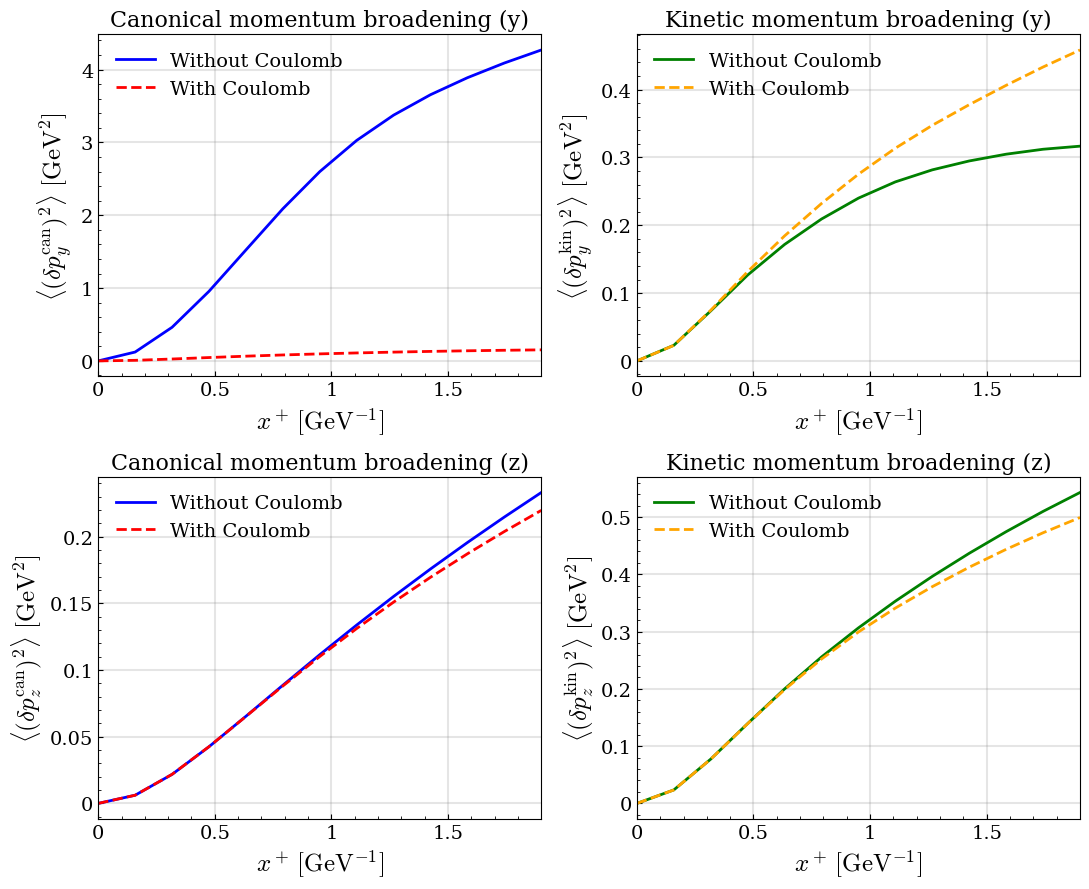

In [6]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.rcParams['font.family'] = 'DejaVu Serif'
plt.rcParams['font.serif'] = ['DejaVu Serif']
plt.rcParams['mathtext.fontset'] = 'cm'

fig, axes = plt.subplots(2, 2, figsize=(11, 9))

labels = ['x', 'y', 'z']
directions = [1, 2]  # y and z
direction_labels = ['y', 'z']

# Plot pcan_sq comparison (left column)
for idx, i in enumerate(directions):
    ax = axes[idx, 0]
    
    line1, = ax.plot(xplus, dpcan_sq_no_coulomb[:, i], linewidth=2.0, 
                     color='blue', label=f'Without Coulomb')
    line2, = ax.plot(xplus, dpcan_sq_coulomb[:, i], linewidth=2.0, 
                     color='red', linestyle='--', label=f'With Coulomb')
    
    ax.set_xlim([0, max(xplus)])
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: '{:g}'.format(x)))
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: '{:g}'.format(x)))
    ax.set_xlabel(r"$x^+\,\mathrm{[GeV^{-1}]}$", fontsize=18)
    ax.set_ylabel(rf"$\langle (\delta p^{{\mathrm{{can}}}}_{labels[i]})^2\rangle\,\,\mathrm{{[GeV^2]}}$", fontsize=18)
    ax.set_title(f'Canonical momentum broadening ({direction_labels[idx]})', fontsize=16)
    ax.grid(color='gray', linestyle='-', linewidth=1.5, alpha=0.2)
    ax.tick_params(axis='both', which='major', direction='in', labelsize=14)
    ax.minorticks_on()
    ax.tick_params(axis='both', which='minor', direction='in')
    ax.legend(fontsize=14, frameon=False)

# Plot pkin_sq comparison (right column)
for idx, i in enumerate(directions):
    ax = axes[idx, 1]
    
    line1, = ax.plot(xplus, dpkin_sq_no_coulomb[:, i], linewidth=2.0, 
                     color='green', label=f'Without Coulomb')
    line2, = ax.plot(xplus, dpkin_sq_coulomb[:, i], linewidth=2.0, 
                     color='orange', linestyle='--', label=f'With Coulomb')
    
    ax.set_xlim([0, max(xplus)])
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: '{:g}'.format(x)))
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: '{:g}'.format(x)))
    ax.set_xlabel(r"$x^+\,\mathrm{[GeV^{-1}]}$", fontsize=18)
    ax.set_ylabel(rf"$\langle (\delta p^{{\mathrm{{kin}}}}_{labels[i]})^2\rangle\,\,\mathrm{{[GeV^2]}}$", fontsize=18)
    ax.set_title(f'Kinetic momentum broadening ({direction_labels[idx]})', fontsize=16)
    ax.grid(color='gray', linestyle='-', linewidth=1.5, alpha=0.2)
    ax.tick_params(axis='both', which='major', direction='in', labelsize=14)
    ax.minorticks_on()
    ax.tick_params(axis='both', which='minor', direction='in')
    ax.legend(fontsize=14, frameon=False)

plt.tight_layout()
plt.savefig(f'pcan_pkin_coulomb_comparison_{quark}_n_{N}_{coulomb_gauge_mode}.png', facecolor='w', dpi=600)
plt.show()

---
## Combined comparison plot

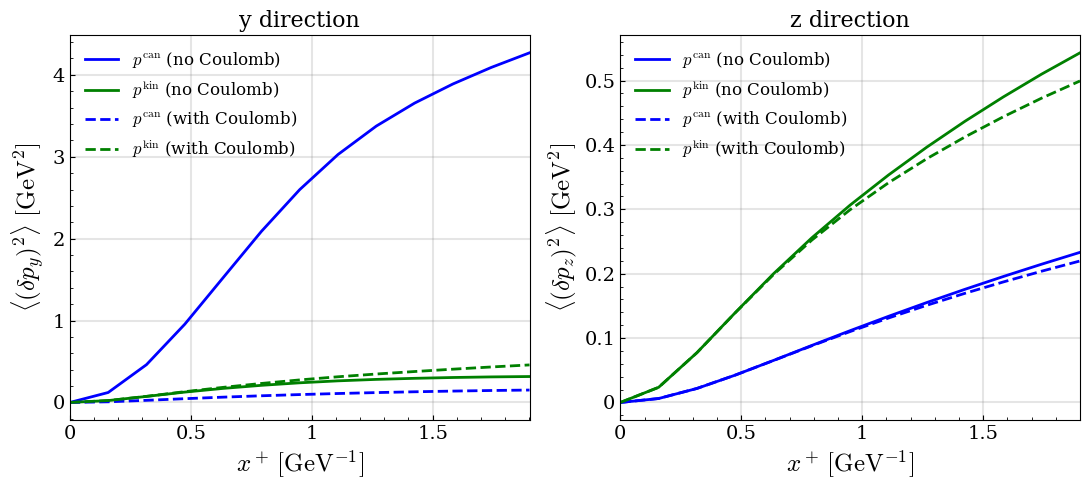

In [7]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.rcParams['font.family'] = 'DejaVu Serif'
plt.rcParams['font.serif'] = ['DejaVu Serif']
plt.rcParams['mathtext.fontset'] = 'cm'

fig, axes = plt.subplots(1, 2, figsize=(11, 5))

labels = ['x', 'y', 'z']
directions = [1, 2]  # y and z
direction_labels = ['y', 'z']

for idx, i in enumerate(directions):
    ax = axes[idx]
    
    # Plot both pcan and pkin for without Coulomb
    line1, = ax.plot(xplus, dpcan_sq_no_coulomb[:, i], linewidth=2.0, 
                     color='blue', label=rf'$p^{{\mathrm{{can}}}}$ (no Coulomb)')
    line2, = ax.plot(xplus, dpkin_sq_no_coulomb[:, i], linewidth=2.0, 
                     color='green', label=rf'$p^{{\mathrm{{kin}}}}$ (no Coulomb)')
    
    # Plot both pcan and pkin for with Coulomb
    line3, = ax.plot(xplus, dpcan_sq_coulomb[:, i], linewidth=2.0, 
                     color='blue', linestyle='--', label=rf'$p^{{\mathrm{{can}}}}$ (with Coulomb)')
    line4, = ax.plot(xplus, dpkin_sq_coulomb[:, i], linewidth=2.0, 
                     color='green', linestyle='--', label=rf'$p^{{\mathrm{{kin}}}}$ (with Coulomb)')
    
    ax.set_xlim([0, max(xplus)])
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: '{:g}'.format(x)))
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: '{:g}'.format(x)))
    ax.set_xlabel(r"$x^+\,\mathrm{[GeV^{-1}]}$", fontsize=18)
    ax.set_ylabel(rf"$\langle (\delta p_{labels[i]})^2\rangle\,\,\mathrm{{[GeV^2]}}$", fontsize=18)
    ax.set_title(f'{direction_labels[idx]} direction', fontsize=16)
    ax.grid(color='gray', linestyle='-', linewidth=1.5, alpha=0.2)
    ax.tick_params(axis='both', which='major', direction='in', labelsize=14)
    ax.minorticks_on()
    ax.tick_params(axis='both', which='minor', direction='in')
    ax.legend(fontsize=12, frameon=False)

plt.tight_layout()
plt.savefig(f'combined_coulomb_comparison_{quark}_n_{N}_{coulomb_gauge_mode}.png', facecolor='w', dpi=600)
plt.show()